## Background and Problem Definition
Fuel efficiency plays an important role in both automotive design and consumer choices. The auto-mpg dataset contains historical information about various car specifications and their fuel efficiency, measured in miles per gallon (MPG). This project explores how vehicle characteristics such as horsepower, weight, and displacement relate to MPG.

The main goal is to build and compare simple and multiple linear regression models in order to see how prediction accuracy changes when more variables are included. By visualizing the data and evaluating model performance, we aim to better understand which factors most influence fuel efficiency.

## Import Required Libraries
Import essential Python libraries for data handling, visualization, and machine learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

## Load Data
Load the `auto-mpg.data` dataset using pandas and assign appropriate column names.

In [3]:
df = pd.read_csv("auto-mpg.data", sep=r'\s+', names=[
    'mpg', 'cylinders', 'displacement', 'horsepower',
    'weight', 'acceleration', 'model_year', 'origin', 'car_name'
])

## Data Description

This dataset consists of 398 rows and 9 columns, each representing specific attributes of a vehicle such as engine performance, weight, and model year.
It contains one target variable, seven numeric columns used for regression modeling, and one string column containing the car names.

Originally, the dataset did not include column headers. We manually assigned appropriate names to each column based on the official dataset documentation provided by the UCI Machine Learning Repository.

The origin column refers to the region where each car was manufactured. Although it appears as a numeric variable in the dataset, the values represent categories (1 for the United States, 2 for Europe, and 3 for Japan). Therefore, origin should be considered a categorical variable rather than a continuous numerical one.

This dataset was originally published by the UCI Machine Learning Repository and is publicly available for research and educational purposes.

Data link:
https://archive.ics.uci.edu/dataset/9/auto+mpg

## Data Cleaning
Handle missing values in the horsepower column, convert data types, and remove unnecessary columns.


In [4]:
df['horsepower'] = df['horsepower'].replace('?', np.nan)
df['horsepower'] = pd.to_numeric(df['horsepower'])
df['horsepower'] = df['horsepower'].fillna(df['horsepower'].median())
df = df.drop(columns=['car_name'])

## Basic EDA
Explore the structure and summary statistics of the dataset.

In [5]:
print(df.describe())
print(df.info())

              mpg   cylinders  displacement  horsepower       weight  \
count  398.000000  398.000000    398.000000  398.000000   398.000000   
mean    23.514573    5.454774    193.425879  104.304020  2970.424623   
std      7.815984    1.701004    104.269838   38.222625   846.841774   
min      9.000000    3.000000     68.000000   46.000000  1613.000000   
25%     17.500000    4.000000    104.250000   76.000000  2223.750000   
50%     23.000000    4.000000    148.500000   93.500000  2803.500000   
75%     29.000000    8.000000    262.000000  125.000000  3608.000000   
max     46.600000    8.000000    455.000000  230.000000  5140.000000   

       acceleration  model_year      origin  
count    398.000000  398.000000  398.000000  
mean      15.568090   76.010050    1.572864  
std        2.757689    3.697627    0.802055  
min        8.000000   70.000000    1.000000  
25%       13.825000   73.000000    1.000000  
50%       15.500000   76.000000    1.000000  
75%       17.175000   79.0000

## Histogram of MPG
Visualize the distribution of the target variable mpg to understand its spread.

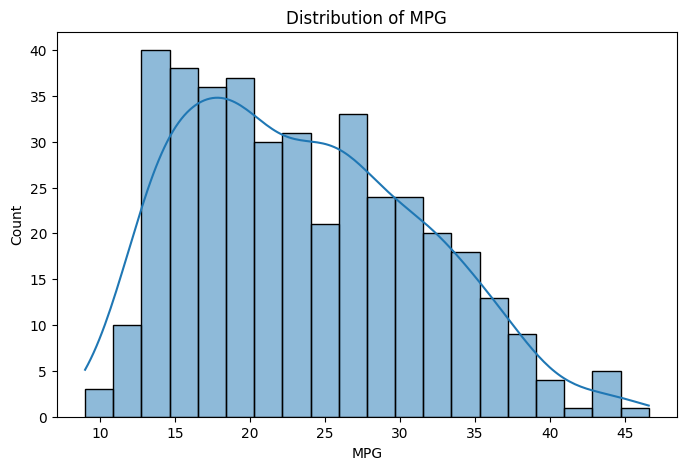

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['mpg'], bins=20, kde=True)
plt.title("Distribution of MPG")
plt.xlabel("MPG")
plt.ylabel("Count")
plt.show()

## Correlation Heatmap
Show correlation among all numeric variables using a heatmap.

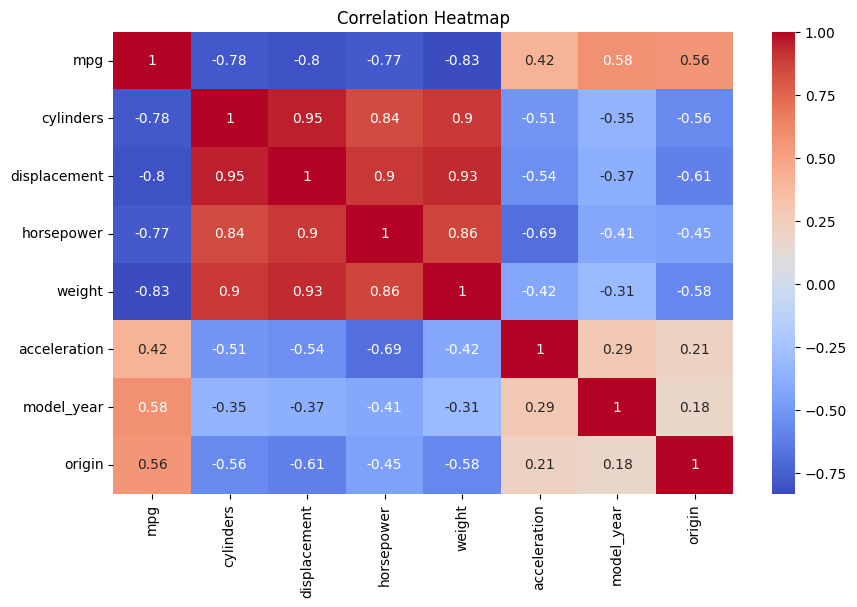

In [7]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

## Scatterplot - Weight vs MPG
Check the linearity between weight and mpg using a scatterplot with regression line.


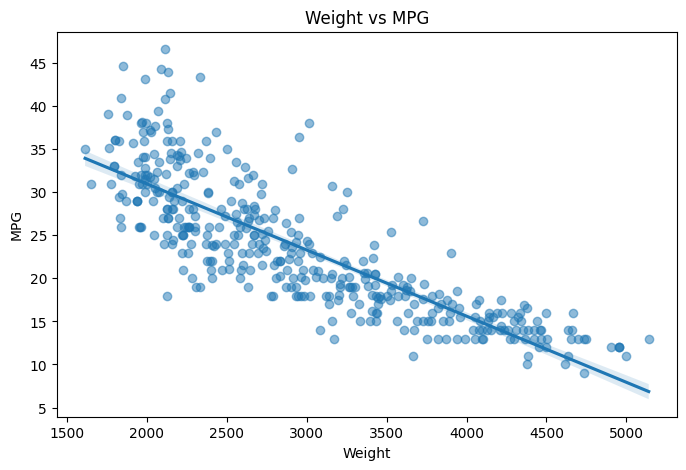

In [12]:
plt.figure(figsize=(8,5))
sns.regplot(x='weight', y='mpg', data=df, scatter_kws={'alpha':0.5})
plt.title("Weight vs MPG")
plt.xlabel("Weight")
plt.ylabel("MPG")
plt.show()

## Simple Linear Regression - Weight to MPG
Train a linear regression model using weight to predict mpg. Split data into train and test sets.


In [13]:
X = df[['weight']]
y = df['mpg']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Simple Linear Regression")
print("R^2:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

Simple Linear Regression
R^2: 0.722971057303075
RMSE: 3.8593860994510765
Slope: -0.00780524235159488
Intercept: 46.78206336645047


## Multiple Linear Regression
Extend the regression model to include all numeric features as predictors for mpg.

In [11]:
X_multi = df.drop(columns=['mpg'])
y_multi = df['mpg']
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)
y_pred_m = model_multi.predict(X_test_m)

print("\nMultiple Linear Regression")
print("R^2:", r2_score(y_test_m, y_pred_m))
print("RMSE:", np.sqrt(mean_squared_error(y_test_m, y_pred_m)))
print("Coefficients:")
for col, coef in zip(X_multi.columns, model_multi.coef_):
    print(f"{col}: {coef:.4f}")


Multiple Linear Regression
R^2: 0.8475304239212403
RMSE: 2.8631707748272683
Coefficients:
cylinders: -0.1568
displacement: 0.0142
horsepower: -0.0132
weight: -0.0067
acceleration: 0.0688
model_year: 0.7950
origin: 1.3230


## Plot - Actual vs Predicted MPG
Compare predicted mpg values against the actual values using a scatterplot.

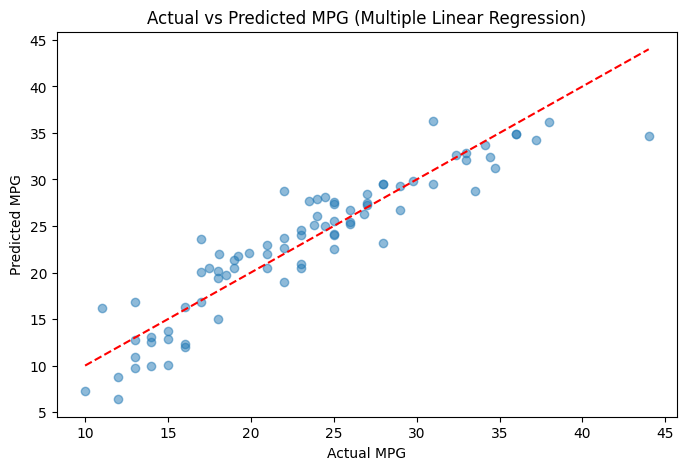

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(y_test_m, y_pred_m, alpha=0.5)
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], 'r--')
plt.xlabel("Actual MPG")
plt.ylabel("Predicted MPG")
plt.title("Actual vs Predicted MPG (Multiple Linear Regression)")
plt.show()

## Conclusion
The auto-mpg dataset project investigated how car specifications impact fuel consumption. After cleaning the data by filling in missing values and reformatting some columns I did an exploratory analysis to see what trends and correlations I could find. One of the big findings was that heavier cars with more horsepower and displacement have lower MPG, and newer cars and cars from certain regions are expected to be more fuel efficient. I then built two regression models to quantify these trends. The first was a simple linear regression that only looked at weight as a vehicle specification. The second was a multiple linear regression that included all numeric features. The simple model performed reasonably well, with an R² of 0.72. The multiple regression model with an R² of 0.85 and lower RMSE did much better. But that comes with the caveat that the more relevant the features are the more accurate the predictions will be. Through this project I got hands on experience building and evaluating regression models. My biggest takeaway though is that data preprocessing and feature selection are key to making accurate and meaningful predictions with real world datasets.